In [102]:
import cv2
import numpy
from google.colab.patches import cv2_imshow
import argparse
import numpy as np


In [103]:
def order_points(pts):
  """
  Order points: top-left, top-right, bottom-right, bottom-left
  """
  rect = np.zeros((4, 2), dtype="float32")
  s = pts.sum(axis=1)
  rect[0] = pts[np.argmin(s)]
  rect[2] = pts[np.argmax(s)]
  diff = np.diff(pts, axis=1)
  rect[1] = pts[np.argmin(diff)]
  rect[3] = pts[np.argmax(diff)]
  return rect

In [104]:
def four_point_transform(image, pts):
  """
  Apply perspective warp given 4 unordered corner points
  """
  rect = order_points(pts)
  (tl, tr, br, bl) = rect

  widthA  = np.sqrt(((br[0] - bl[0]) ** 2) + ((br[1] - bl[1]) ** 2))
  widthB  = np.sqrt(((tr[0] - tl[0]) ** 2) + ((tr[1] - tl[1]) ** 2))
  maxWidth  = max(int(widthA),  int(widthB))

  heightA = np.sqrt(((tr[0] - br[0]) ** 2) + ((tr[1] - br[1]) ** 2))
  heightB = np.sqrt(((tl[0] - bl[0]) ** 2) + ((tl[1] - bl[1]) ** 2))
  maxHeight = max(int(heightA), int(heightB))

  dst = np.array([
      [0,           0],
      [maxWidth-1, 0],
      [maxWidth-1, maxHeight-1],
      [0,           maxHeight-1],
  ], dtype="float32")

  M = cv2.getPerspectiveTransform(rect, dst)
  warped = cv2.warpPerspective(image, M, (maxWidth, maxHeight))
  return warped





In [105]:
def scan_document(image_path):
  # Step 1: Load image and resize
  image = cv2.imread(image_path)
  if image.shape[0] > image.shape[1]:
    target_height = 800
  else:
    target_height = 500
  ratio = image.shape[0]/ target_height
  orig = image.copy()
  image = cv2.resize(image, (int(image.shape[1] / ratio), target_height))

  # Step 2: Grayscale -> Blur -> Canny
  gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
  gray = cv2.GaussianBlur(gray, (5,5), 0)
  edged = cv2.Canny(gray, 50, 150)

  # Step 3: find and approximate contours
  cnts, _ = cv2.findContours(edged.copy(), cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
  cnts = sorted(cnts, key=cv2.contourArea, reverse=True)[:5]

  screenCnt = None
  for c in cnts:
    peri = cv2.arcLength(c, True)
    approx = cv2.approxPolyDP(c, 0.02 * peri, True)
    if len(approx) == 4:
      screenCnt = approx
      break

  if screenCnt is None:
    print("No document found. Try adjusting Canny thresholds.")
    return

  warped = four_point_transform(orig, screenCnt.reshape(4, 2) * ratio)

  wraped_gray = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY)
  scanned = cv2.adaptiveThreshold(wraped_gray,
                                  255,
                                  cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                  cv2.THRESH_BINARY,
                                  15,
                                  10)

  # ------- DISPLAY --------------

  cv2_imshow(image)
  cv2_imshow( edged)
  cv2_imshow( warped)
  cv2_imshow(scanned)
  cv2.waitKey(0)

  cv2.imwrite("scanned_output5.jpg", scanned)
  print("✅ Saved: scanned_output.jpg")



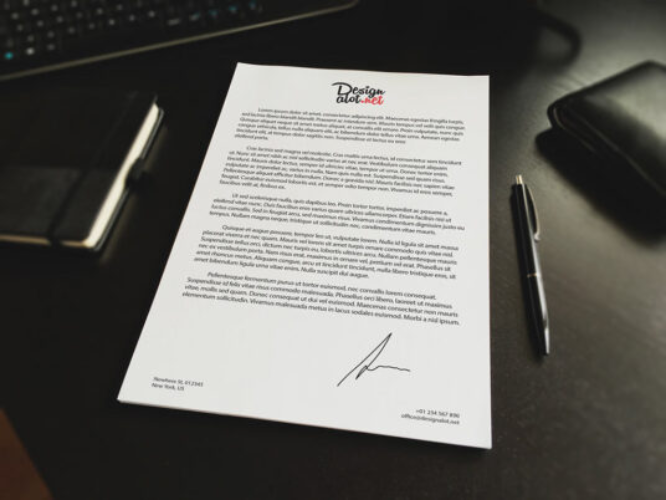

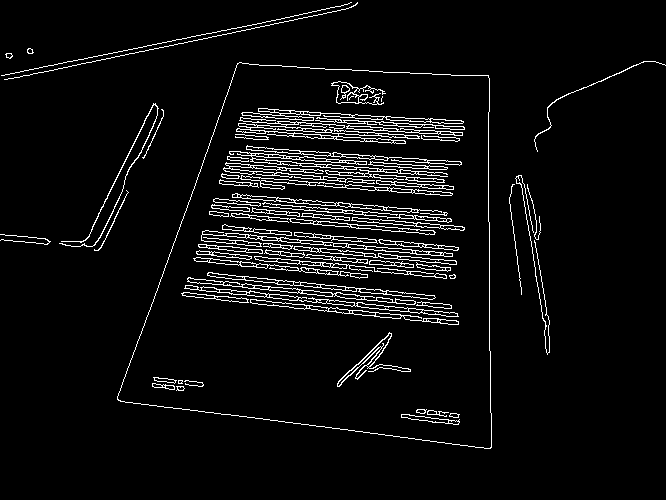

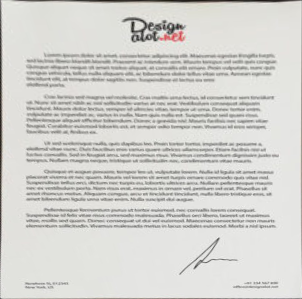

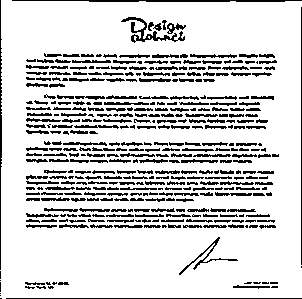

✅ Saved: scanned_output.jpg


In [106]:
if __name__ == "__main__":
  image_path = "/content/Image1.jpg"
  scan_document(image_path)